# Pump Data Exploration

This notebook loads, inspects, validates, and explores the pump sensor dataset before later predictive-maintenance feature engineering.


## 1. Load Dataset

The reusable project loader is used to read the raw pump dataset, with the timestamp column parsed as datetime.


In [2]:
from predictive_maintenance.data.load_data import load_data

df = load_data("../data/raw/pump_data.csv")


## 2. Inspect Dataset Structure

This section reviews the dataset shape, columns, sample rows, and data types.


In [3]:
print(f"Shape: {df.shape}")
print("Columns:")
print(df.columns.tolist())

display(df.head())

df.dtypes


Shape: (720050, 7)
Columns:
['timestamp', 'pump_throughput_m3ph', 'operating_pressure_bar', 'vibration_mm_s', 'bearing_temp_C', 'status', 'pump_number']


,timestamp,pump_throughput_m3ph,operating_pressure_bar,vibration_mm_s,bearing_temp_C,status,pump_number
0,2025-04-15 20:14:00.388595,101.948189,9.911733,1.151807,63.317134,RUNNING,1
1,2025-04-15 20:24:00.388595,97.350999,10.015090,1.222389,67.622323,RUNNING,1
2,2025-04-15 20:34:00.388595,98.642862,9.890661,1.284898,67.834281,RUNNING,1
3,2025-04-15 20:44:00.388595,101.125591,10.136244,1.010065,64.876550,RUNNING,1
4,2025-04-15 20:54:00.388595,102.167705,10.048706,0.981551,69.590331,RUNNING,1


timestamp                 datetime64[us]
pump_throughput_m3ph             float64
operating_pressure_bar           float64
vibration_mm_s                   float64
bearing_temp_C                   float64
status                               str
pump_number                        int64
dtype: object

## 3. Data Quality Checks

This section verifies that the dataset is suitable for downstream analysis by checking missing values, duplicate rows, schema expectations, and validation results.


In [4]:
quality_summary = {
    "missing_values": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "timestamp_dtype": str(df["timestamp"].dtype),
    "pump_count": int(df["pump_number"].nunique()),
}

quality_summary


{'missing_values': 0,
 'duplicate_rows': 0,
 'timestamp_dtype': 'datetime64[us]',
 'pump_count': 50}

## 4. Pump Status Distribution

This section analyzes RUNNING versus DOWN observations and checks for class imbalance.


In [19]:
status_counts = df["status"].value_counts()

status_counts

status
RUNNING    671600
DOWN        48450
Name: count, dtype: int64

### Status Percentages


In [6]:
status_percentages = df["status"].value_counts(normalize=True) * 100

status_percentages

status
RUNNING    93.271301
DOWN        6.728699
Name: proportion, dtype: float64

### Status Distribution Visualization


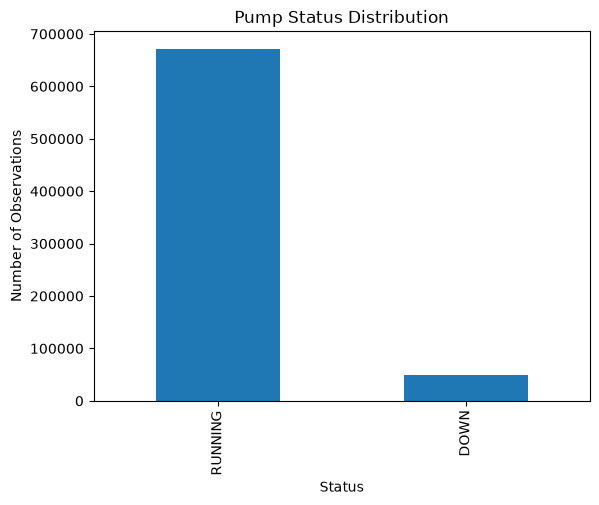

In [7]:
import matplotlib.pyplot as plt

df["status"].value_counts().plot(kind="bar")

plt.title("Pump Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Observations")
plt.show()

### Status Summary Table


In [8]:
status_summary = df["status"].value_counts().to_frame(name="count")
status_summary["percentage"] = (
    df["status"].value_counts(normalize=True) * 100
)

status_summary

,count,percentage
status,,
RUNNING,671600,93.271301
DOWN,48450,6.728699


## 5. Initial Observations

The dataset contains 50 pumps, has no missing values or duplicate rows, timestamps are suitable for chronological analysis, and the target is imbalanced with substantially more RUNNING than DOWN observations.

Future model evaluation should consider precision, recall, F1, ROC-AUC, and PR-AUC rather than accuracy alone.


## 6. Identify Distinct Downtime Events

A downtime event begins when a pump transitions from RUNNING to DOWN. Consecutive DOWN rows belong to the same event.


In [9]:
downtime_df = df.copy()
downtime_df = downtime_df.sort_values(["pump_number", "timestamp"])


### Previous Pump Status

The previous status for each pump is needed to detect transitions between operating states.


In [10]:
downtime_df["previous_status"] = downtime_df.groupby("pump_number")["status"].shift(1)


### Detect Downtime Starts

A downtime event starts when the current status is DOWN and the previous status was RUNNING.


In [11]:
downtime_df["downtime_start"] = (
    (downtime_df["status"] == "DOWN")
    & (downtime_df["previous_status"] == "RUNNING")
)


### Extract Distinct Downtime Events


In [12]:
downtime_events = downtime_df[downtime_df["downtime_start"] == True]


In [13]:
downtime_events.head()


,timestamp,pump_throughput_m3ph,operating_pressure_bar,vibration_mm_s,bearing_temp_C,status,pump_number,previous_status,downtime_start
1238,2025-04-24 10:34:00.388595,0.0,0.0,0.0,25.500748,DOWN,1,RUNNING,True
2596,2025-05-03 20:54:00.388595,0.0,0.0,0.0,27.639492,DOWN,1,RUNNING,True
4053,2025-05-13 23:44:00.388595,0.0,0.0,0.0,27.888169,DOWN,1,RUNNING,True
5287,2025-05-22 13:24:00.388595,0.0,0.0,0.0,20.697955,DOWN,1,RUNNING,True
6496,2025-05-30 22:54:00.388595,0.0,0.0,0.0,20.702499,DOWN,1,RUNNING,True


### Downtime Event Counts


In [14]:
total_downtime_events = downtime_df["downtime_start"].sum()

total_downtime_events


np.int64(500)

## 7. Downtime Frequency by Pump

This section summarizes the number of distinct downtime events experienced by each pump and checks whether downtime is concentrated in a small number of pumps or distributed relatively evenly across the fleet.


### Downtime Events per Pump

Each row in `downtime_events` represents one distinct RUNNING to DOWN transition, so grouping by `pump_number` and counting rows gives the number of downtime events for each pump.


In [15]:
downtime_events_per_pump = downtime_events.groupby("pump_number").size()

downtime_events_per_pump


pump_number
1     10
2     11
3     10
4     10
5      9
6     10
7      9
8      9
9     10
10     9
11     9
12    10
13     9
14    10
15    11
16    10
17    10
18    11
19    11
20    10
21    10
22     9
23     9
24    10
25    10
26    10
27    10
28    11
29    12
30    10
31    10
32    10
33    11
34    10
35     9
36    10
37    11
38    10
39    10
40    10
41     9
42    10
43    10
44    10
45    10
46    10
47     9
48    11
49    10
50    11
dtype: int64

### Downtime Frequency Summary

These statistics summarize the typical number of downtime events across the 50 pumps.


In [24]:
downtime_frequency_summary = {
    "mean": downtime_events_per_pump.mean(),
    "median": downtime_events_per_pump.median(),
    "minimum": downtime_events_per_pump.min(),
    "maximum": downtime_events_per_pump.max(),
}

downtime_frequency_summary

{'mean': np.float64(10.0),
 'median': np.float64(10.0),
 'minimum': np.int64(9),
 'maximum': np.int64(12)}

### Pumps with Highest and Lowest Downtime Frequency

This identifies whether any individual pumps experience noticeably more or fewer downtime events than the rest of the fleet.


In [25]:
highest_downtime_events = downtime_events_per_pump.max()
lowest_downtime_events = downtime_events_per_pump.min()

highest_lowest_downtime = {
    "highest_downtime_pumps": downtime_events_per_pump[
        downtime_events_per_pump == highest_downtime_events
    ].index.tolist(),

    "highest_downtime_events": highest_downtime_events,

    "lowest_downtime_pumps": downtime_events_per_pump[
        downtime_events_per_pump == lowest_downtime_events
    ].index.tolist(),

    "lowest_downtime_events": lowest_downtime_events,
}

highest_lowest_downtime

{'highest_downtime_pumps': [29],
 'highest_downtime_events': np.int64(12),
 'lowest_downtime_pumps': [5, 7, 8, 10, 11, 13, 22, 23, 35, 41, 47],
 'lowest_downtime_events': np.int64(9)}

### Downtime Frequency Visualization

The chart compares the number of distinct downtime events across all pumps.


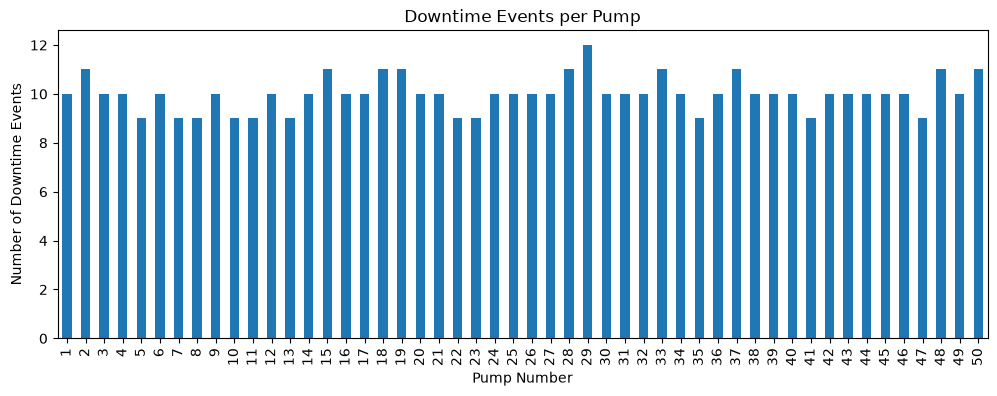

In [21]:
downtime_events_per_pump.plot(kind="bar", figsize=(12, 4))

plt.title("Downtime Events per Pump")
plt.xlabel("Pump Number")
plt.ylabel("Number of Downtime Events")
plt.show()


### Observation

Downtime events appear relatively evenly distributed across the pump fleet, rather than being concentrated in only a small number of pumps. This provides failure examples across many different pump IDs for later predictive-maintenance analysis.
